In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.animation as animation
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import preprocessing
from scipy.special import legendre

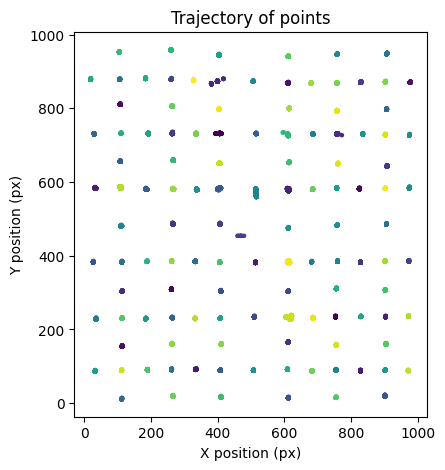

In [2]:
filepath = "6by6/Videos"
name = "2_2_25.MP4"
freq = 2
framepath = f"{filepath}/{name}_frames"
raw_data = pd.read_csv(f'{framepath}/raw_data_rate2.csv')
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.scatter(raw_data['X'], raw_data['Y'], c=raw_data['Label'], s=5)
# plt.gca().invert_yaxis()
plt.ylabel("Y position (px)")
plt.xlabel("X position (px)")
# plt.legend(loc='upper left')
plt.title("Trajectory of points")
stimulation_point_label=15

# rotation = np.pi/2
# x = raw_data['X'].copy()
# y = raw_data['Y'].copy()
# raw_data['X'] = np.cos(rotation) * x - np.sin(rotation) * y
# raw_data['Y'] = np.sin(rotation) * x + np.cos(rotation) * y
# plt.subplot(122)
# plt.scatter(raw_data['X'], raw_data['Y'], c=raw_data['Label'], s=5)
# # plt.gca().invert_yaxis()
# plt.ylabel("Y position (px)")
# plt.xlabel("X position (px)")
# # plt.legend(loc='upper left')
# plt.title("Trajectory of points for experiment")

plt.show()

[55 54 53 52 51 49 50 47 48 45 46 43 44 42 41 40 39 38 36 30 32 37 35 33
 31 34 29 28 26 27 25 23 21 24 19 22 17 20 18 16 14 13 15 12  4  6 10  8
  9 11  5  7  3  1  2  0]


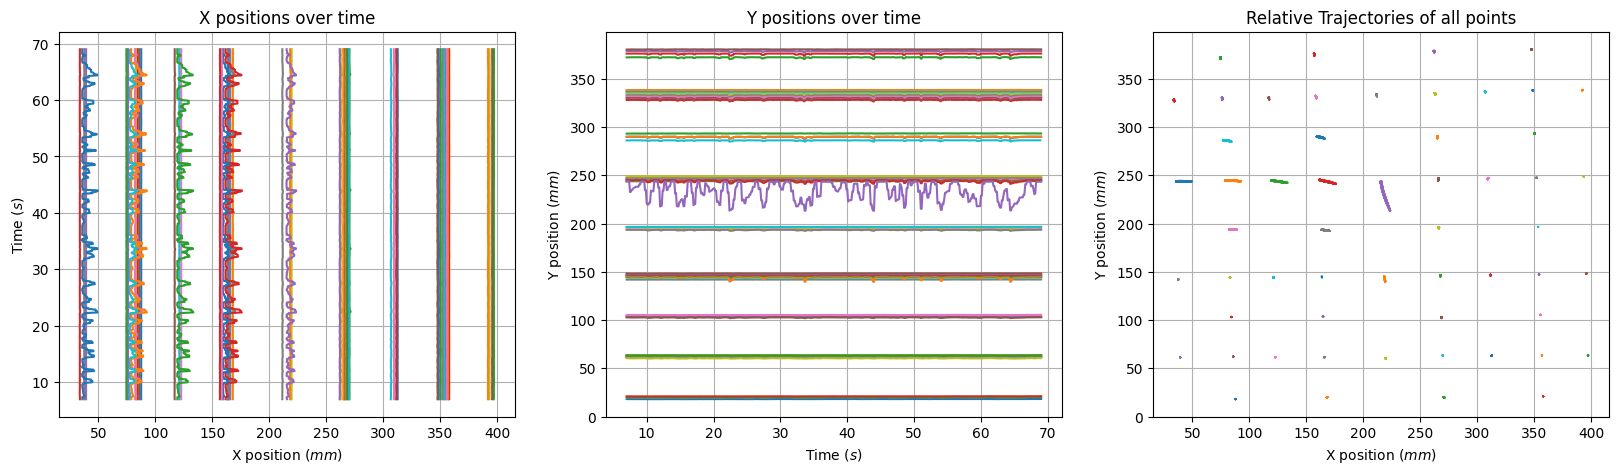

In [255]:
y_ranges = [0, 100, 200, 320, 450, 540, 700, 800, 950, 1070]
x_ranges = [0, 150, 275, 400, 500, 650, 750, 850, 950, 1100]

j = 0
for m in range(len(y_ranges)-1):
    for k in range(len(x_ranges)-1):
        idx = (raw_data['X'] >= x_ranges[k]) & (raw_data['X'] <= x_ranges[k+1]) & (raw_data['Y'] >= y_ranges[m]) & (raw_data['Y'] <= y_ranges[m+1])
        if len(raw_data[idx]) > 0:
            raw_data.loc[idx, 'Label'] = j
            j += 1

print(raw_data['Label'].unique())

raw_data = raw_data.sort_values(by=['Label', 'Time'])
conversion_factor = 0.3839667800218745 #mm/px
raw_data['Xmm'] = raw_data['X']*conversion_factor
raw_data['Ymm'] = raw_data['Y']*conversion_factor
start = 7
end = 69
raw_data['Time_s'] = raw_data['Time']*(end-start)/(raw_data['Time'].max()-raw_data['Time'].min()) + start


min_label = int(raw_data['Label'].min())
max_label = int(raw_data['Label'].max())
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
for i in range(min_label, max_label+1):
    label = i
    specific_label = raw_data[raw_data['Label'] == label]

    ax1.plot(specific_label['Xmm'], specific_label['Time_s'], label=label)
    ax2.plot(specific_label['Time_s'], specific_label['Ymm'], label=label)
    ax3.plot(specific_label['Xmm'], specific_label['Ymm'], label=label)

ax1.set_xlabel("X position ($mm$)")
ax1.set_ylabel("Time ($s$)")
ax1.grid(True)
# ax1.legend()
ax1.set_title("X positions over time")

ax2.set_xlabel("Time ($s$)")
ax2.set_ylabel("Y position ($mm$)")
ax2.grid(True)
# ax2.invert_yaxis()
# ax2.legend()
ax2.set_title("Y positions over time")

ax3.set_xlabel("X position ($mm$)")
ax3.set_ylabel("Y position ($mm$)")
ax3.grid(True)
# ax3.invert_yaxis()
# ax3.legend()
ax3.set_title("Relative Trajectories of all points")

plt.show()

In [228]:
# sim_data = np.load("SMASIS_sims/diffconstraints_mm_g_s_FiberSim_4rods_15sec_L5.00e-01m_R1.00e-03m_dx10mm_YM1.00e+07Pa_Density1.00e+03kgmm-3_Damping10_TF1e-02N_PF-2e-02Nspline_k1e+09_kt1e+09_fps250_stepskip800_1.npz", allow_pickle=True)
# rods_history = sim_data['rods_history']
# time_sim = rods_history[0]['time']
# hor_rod_0 = np.array(rods_history[0]['position'])
# hor_rod_1 = np.array(rods_history[1]['position'])
# ver_rod_0 = np.array(rods_history[2]['position'])
# ver_rod_1 = np.array(rods_history[3]['position'])


# x = np.array([hor_rod_0[..., 0, 17], hor_rod_0[..., 0, 12], hor_rod_0[..., 0, 25], hor_rod_0[..., 0, 37], hor_rod_0[..., 0, 43],
#               hor_rod_1[..., 0, 17], hor_rod_1[..., 0, 12], hor_rod_1[..., 0, 25], hor_rod_1[..., 0, 37], hor_rod_1[..., 0, 43],
#               ver_rod_0[..., 0, 17], ver_rod_0[..., 0, 12], ver_rod_0[..., 0, 25], ver_rod_0[..., 0, 37], ver_rod_0[..., 0, 43],
#               ver_rod_1[..., 0, 17], ver_rod_1[..., 0, 12], ver_rod_1[..., 0, 25], ver_rod_1[..., 0, 37], ver_rod_1[..., 0, 43]])
# y = np.array([hor_rod_0[..., 1, 17], hor_rod_0[..., 1, 12], hor_rod_0[..., 1, 25], hor_rod_0[..., 1, 37], hor_rod_0[..., 1, 43],
#               hor_rod_1[..., 1, 17], hor_rod_1[..., 1, 12], hor_rod_1[..., 1, 25], hor_rod_1[..., 1, 37], hor_rod_1[..., 1, 43],
#               ver_rod_0[..., 1, 17], ver_rod_0[..., 1, 12], ver_rod_0[..., 1, 25], ver_rod_0[..., 1, 37], ver_rod_0[..., 1, 43],
#               ver_rod_1[..., 1, 17], ver_rod_1[..., 1, 12], ver_rod_1[..., 1, 25], ver_rod_1[..., 1, 37], ver_rod_1[..., 1, 43]])
# z = np.array([hor_rod_0[..., 2, 17], hor_rod_0[..., 2, 12], hor_rod_0[..., 2, 25], hor_rod_0[..., 2, 37], hor_rod_0[..., 2, 43],
#               hor_rod_1[..., 2, 17], hor_rod_1[..., 2, 12], hor_rod_1[..., 2, 25], hor_rod_1[..., 2, 37], hor_rod_1[..., 2, 43],
#               ver_rod_0[..., 2, 17], ver_rod_0[..., 2, 12], ver_rod_0[..., 2, 25], ver_rod_0[..., 2, 37], ver_rod_0[..., 2, 43],
#               ver_rod_1[..., 2, 17], ver_rod_1[..., 2, 12], ver_rod_1[..., 2, 25], ver_rod_1[..., 2, 37], ver_rod_1[..., 2, 43]])

# x = -x
# y = -y

# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# ax1.plot(x.T, time_sim)
# ax2.plot(time_sim, y.T)
# ax3.plot(x.T, y.T)

# ax1.set_xlabel("X position ($mm$)")
# ax1.set_ylabel("Time ($s$)")
# ax1.grid(True)
# # ax1.legend()
# ax1.set_title("X positions over time")

# ax2.set_xlabel("Time ($s$)")
# ax2.set_ylabel("Y position ($mm$)")
# ax2.grid(True)
# # ax2.invert_yaxis()
# # ax2.legend()
# ax2.set_title("Y positions over time")

# ax3.set_xlabel("X position ($mm$)")
# ax3.set_ylabel("Y position ($mm$)")
# ax3.grid(True)
# # ax3.invert_yaxis()
# # ax3.legend()
# ax3.set_title("Trajectories of points for simulation")

# plt.show()

In [3]:
clean_data = pd.read_csv(f'{framepath}/clean_data_final_rate2.csv')
clean_data['Time_s'] = clean_data['Time']/60
min_label = clean_data['Label'].min()
max_label = clean_data['Label'].max()
# x = clean_data['X'].copy()
# y = clean_data['Y'].copy()
# clean_data['X'] = np.cos(rotation) * x - np.sin(rotation) * y
# clean_data['Y'] = np.sin(rotation) * x + np.cos(rotation) * y
# x = clean_data['Xmm'].copy()
# y = clean_data['Ymm'].copy()
# clean_data['Xmm'] = np.cos(rotation) * x - np.sin(rotation) * y
# clean_data['Ymm'] = np.sin(rotation) * x + np.cos(rotation) * y
# 4by 4 0.3839667800218745
# 3by 3 0.34676156759592264

In [4]:
print(clean_data['Label'].unique())

[115 114 116 118 119 117 103 106 101 102 104 105 107 111 112 113 109 110
 108  95  96  98 100  97  99  83  84  87  88  90  92  82  85  86  89  91
  93  94  77  76  79  78  80  81  63  72  75  65  73  64  67  69  71  74
  66  68  70  58  59  62  61  57  60  45  46  48  52  53  54  55  56  44
  47  50  49  51  42  39  40  41  43  38  35  31  28  32  33  34  36  37
  26  27  29  30  25  22  20  21  24  23  19   7  10  13  11  14  15  16
   6   8   9  17  18  12   5   1   2   3   4   0]


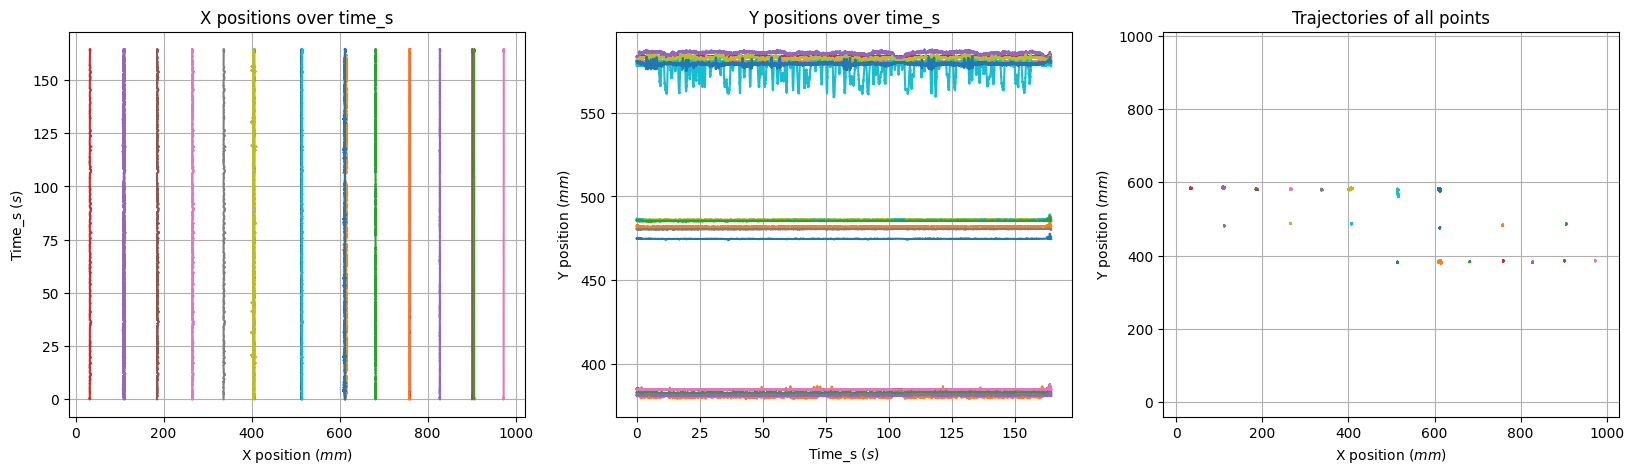

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
for i in range(50, 71):
    label = i
    specific_label = clean_data[clean_data['Label'] == label]

    ax1.plot(specific_label['X'], specific_label['Time_s'], label=label)
    ax2.plot(specific_label['Time_s'], specific_label['Y'], label=label)
    ax3.plot(specific_label['X'], specific_label['Y'], label=label)

ax1.set_xlabel("X position ($mm$)")
ax1.set_ylabel("Time_s ($s$)")
ax1.grid(True)
# ax1.legend()
ax1.set_title("X positions over time_s")

ax2.set_xlabel("Time_s ($s$)")
ax2.set_ylabel("Y position ($mm$)")
ax2.grid(True)
# ax2.invert_yaxis()
# ax2.legend()
ax2.set_title("Y positions over time_s")

ax3.set_xlabel("X position ($mm$)")
ax3.set_ylabel("Y position ($mm$)")
ax3.grid(True)
# ax3.invert_yaxis()
# ax3.legend()
ax3.set_title("Trajectories of all points")
ax3.set_ylim(np.min(clean_data['Y'])-50, np.max(clean_data['Y'])+50)
ax3.set_xlim(np.min(clean_data['X'])-50, np.max(clean_data['X'])+50)

plt.show()

In [12]:
origin_x = (clean_data['X'].max()+clean_data['X'].min())/2 #clean_data['X'].min()
origin_y = (clean_data['Y'].max()+clean_data['Y'].min())/2 #clean_data['Y'].min()
time_min = clean_data['Time_s'].min()
time_max = clean_data['Time_s'].max()

In [13]:
stimulation_point_label = 34
clean_data['Relative X'] = clean_data['X'] - origin_x
clean_data['Relative Y'] = clean_data['Y'] - origin_y
clean_data['Time_s'] = clean_data['Time_s'] - time_min
stimulation_point  = clean_data[clean_data['Label'] == stimulation_point_label]

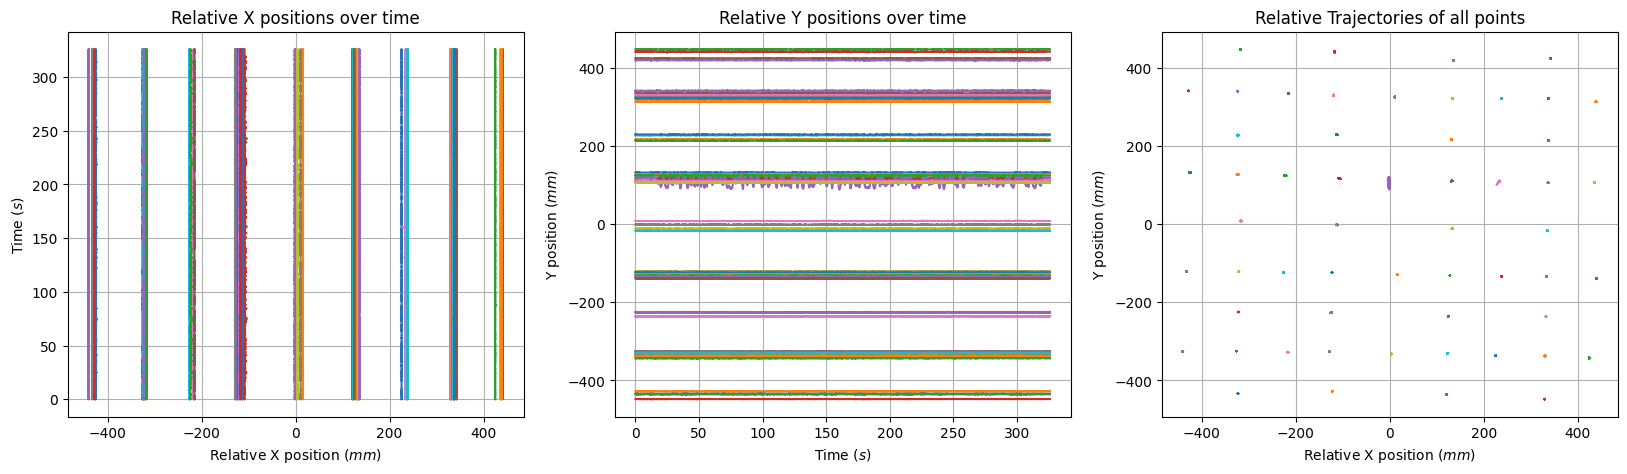

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
for i in range(min_label, max_label+1):
    label = i
    specific_label = clean_data[clean_data['Label'] == label]

    ax1.plot(specific_label['Relative X'], specific_label['Time_s'], label=label)
    ax2.plot(specific_label['Time_s'], specific_label['Relative Y'], label=label)
    ax3.plot(specific_label['Relative X'], specific_label['Relative Y'], label=label)

ax1.set_xlabel("Relative X position ($mm$)")
ax1.set_ylabel("Time ($s$)")
ax1.grid(True)
# ax1.legend()
ax1.set_title("Relative X positions over time")

ax2.set_xlabel("Time ($s$)")
ax2.set_ylabel("Y position ($mm$)")
ax2.grid(True)
# ax2.invert_yaxis()
# ax2.legend()
ax2.set_title("Relative Y positions over time")

ax3.set_xlabel("Relative X position ($mm$)")
ax3.set_ylabel("Y position ($mm$)")
ax3.grid(True)
# ax3.invert_yaxis()
# ax3.legend()
ax3.set_title("Relative Trajectories of all points")

plt.show()

In [15]:
clean_data.columns

Index(['Label', 'X', 'Y', 'Time', 'Time_s', 'Relative X', 'Relative Y'], dtype='object')

In [18]:
label_num_list = [len(clean_data[clean_data['Label'] == i]) for i in range(min_label, max_label+1)]
print(label_num_list)
print(np.min(label_num_list), np.max(label_num_list))

[19216, 19216, 19216, 19215, 19217, 19217, 19217, 19217, 19217, 19216, 19216, 19216, 19216, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19218, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217, 19217]
19215 19218


In [25]:
min_shape = np.min(label_num_list)
print(min_shape)

for i in range(min_label, max_label+1):
    if i != stimulation_point_label:
        one_over_time = clean_data[clean_data['Label']==i]
        one_over_time = one_over_time.iloc[:, 5:]
        array = one_over_time.to_numpy()
        array = array[:min_shape, :]
        if i == 0:
            output = array
        else:
            output = np.hstack([output, array])

print(output.shape)

output = np.nan_to_num(output, nan=0)
# scaler = preprocessing.StandardScaler().fit(output)
# output = scaler.transform(output)

19215
(19215, 110)


In [237]:
motor_data = np.load(f'{framepath[:-7]}.npz', allow_pickle=True)
motor_data = pd.DataFrame(motor_data['data'][0])
motor_data['GoalPos'] = motor_data['GoalPos'] * (300/1023)
motor_data['PresPos'] = motor_data['PresPos'] * (300/1023)
# print(motor_data)
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.plot(motor_data['Time'], motor_data['PresPos'], '-o', label='PresPos')
plt.xlabel("Time ($s$)")
plt.ylabel("Motor position (deg)")
plt.title("Motor position over time")
plt.grid(True)
plt.legend()

time_diff = motor_data['Time'].iloc[1] - motor_data['Time'].iloc[0]
num_pre = 8
num_post = 5
pre_data = pd.DataFrame({'Time': [motor_data['Time'].iloc[0]-time_diff*i for i in range(1, num_pre+1)], 'GoalPos': [motor_data['GoalPos'][0] for i in range(num_pre)], 'PresPos': [motor_data['PresPos'][0] for i in range(num_pre)]})
post_data = pd.DataFrame({'Time': [motor_data['Time'].iloc[-1]+time_diff*i for i in range(1, num_post+1)], 'GoalPos': [motor_data['GoalPos'][len(motor_data)-1] for i in range(num_post)], 'PresPos': [motor_data['PresPos'][len(motor_data)-1] for i in range(num_post)]})
# plt.plot(time, input_signal, '-o')
# plt.title("Input signal")
# plt.show()
pre_data['Time'] = pre_data['Time'] - pre_data['Time'].iloc[-1]
pre_data = pre_data.sort_values(by='Time', ascending=True, ignore_index=True)
motor_data['Time'] = motor_data['Time'] + pre_data['Time'].iloc[-1]
post_data['Time'] = post_data['Time'] + pre_data['Time'].iloc[-1]
motor_data = pd.concat([pre_data, motor_data, post_data], ignore_index=True)
motor_data['PresPos'] -= 150
# print(motor_data)

plt.subplot(122)
plt.plot(motor_data['Time'], motor_data['PresPos'], '-o', label='PresPos')
plt.plot(stimulation_point['Time_s'], stimulation_point['Relative Y'], '-o', label='Stimulation point')
plt.xlabel("Time ($s$)")
plt.ylabel("Present Position (deg)")
plt.title("Motor position over time")
plt.grid(True)
plt.xlim(0, 10)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'SMASIS_exp/motor_pulling_exp//stiffness03_assymmetric_random_2.npz'

In [ ]:
# indices = np.searchsorted(motor_data["Time"], stimulation_point["Time_s"][:min_shape])
# input_signal = motor_data["PresPos"].iloc[indices].to_numpy()
# plt.figure(figsize=(10, 5))
# plt.plot(stimulation_point['Time_s'][:min_shape], input_signal, '-o', label='Input signal')
# plt.plot(stimulation_point['Time_s'], stimulation_point['Relative Y'], '-o', label='Stimulation point')
# plt.grid(True)
# plt.xlabel("Time ($s$)")
# plt.ylabel("Input signal (deg)")
# plt.title("Input signal over time")
# plt.legend()
# plt.show()

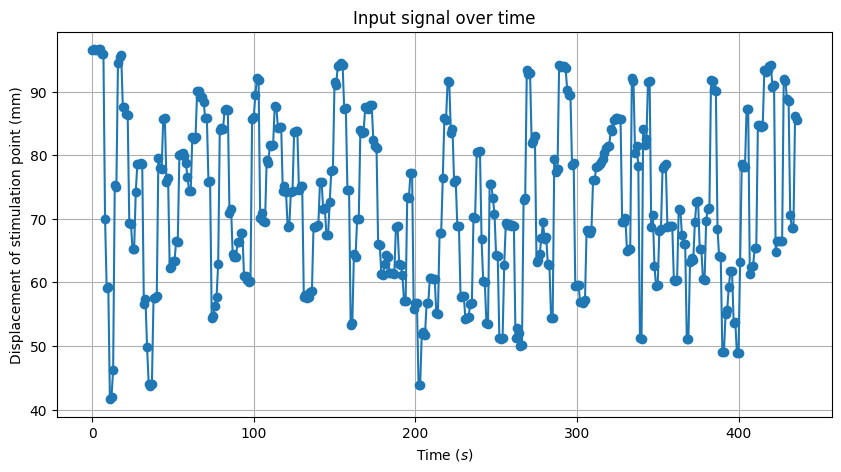

In [ ]:
input_signal = stimulation_point['Relative Y'].to_numpy()
input_signal = input_signal[:min_shape]
plt.figure(figsize=(10, 5))
plt.plot(input_signal, '-o', label='Input signal')
# plt.plot(output[:, 1:output.shape[1]:2], '-o', label='Output signal')
plt.grid(True)
plt.xlabel("Time ($s$)")
plt.ylabel("Displacement of stimulation point (mm)")
plt.title("Input signal over time")
plt.show()

In [ ]:
input_signal = input_signal.reshape(-1, 1)
input_signal = np.nan_to_num(input_signal, nan=0)
# scaler = preprocessing.StandardScaler().fit(input_signal)
# input_signal = scaler.transform(input_signal)
input_signal = 0 + (input_signal - np.min(input_signal)) * (1 - 0) / (np.max(input_signal) - np.min(input_signal))

In [ ]:
# print(output.shape, input_signal.shape)
# output = np.vstack([output, output])
# input_signal = np.vstack([input_signal, input_signal])
# print(output.shape, input_signal.shape)

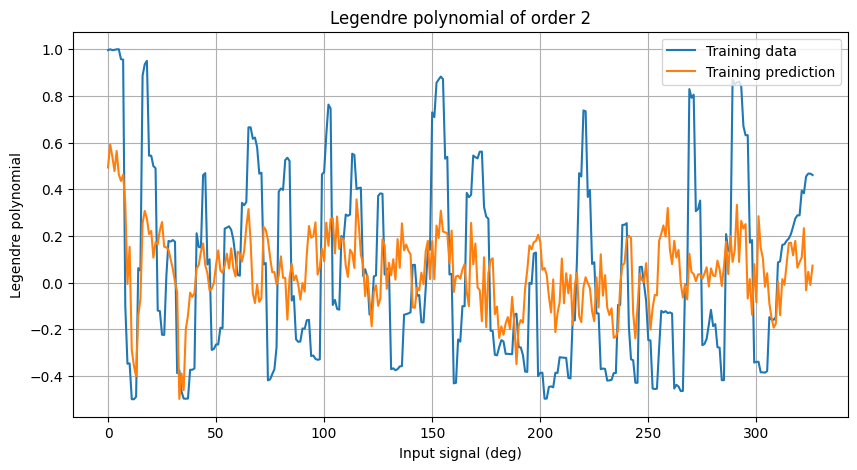

In [ ]:
test_size = 0.25
alpha = 0.5
clf = Ridge(alpha=alpha)

legendre_capacity_train = []
legendre_capacity_test = []
legendre_R2_train = []
legendre_R2_test = []
n_max = 10
for n in range(1, n_max+1):
    x = output
    polynomial = legendre(n)
    y = polynomial(input_signal)

    x_train, x_test, y_train, y_test = train_test_split(x, y, 
                                                        test_size=test_size,
                                                        random_state=42,
                                                        shuffle=False)

    clf.fit(x_train, y_train)

    # Training capacity
    y_train_pred = clf.predict(x_train)

    MSE = mean_squared_error(y_train, y_train_pred)
    z2 = (1/len(y_train)) * np.sum((y_train)**2)
    C = 1 - MSE/z2
    R2_train = r2_score(y_train, y_train_pred)

    legendre_capacity_train.append(C)
    legendre_R2_train.append(R2_train)

    # Testing capacity
    y_test_pred = clf.predict(x_test)

    MSE = mean_squared_error(y_test, y_test_pred)
    z2 = (1/len(y_test)) * np.sum((y_test)**2)
    C = 1 - MSE/z2
    R2_test = r2_score(y_test, y_test_pred)

    legendre_capacity_test.append(C)
    legendre_R2_test.append(R2_test)

    if n == 2:
        plt.figure(figsize=(10, 5))
        plt.plot(y_train, '-', label='Training data')
        plt.plot(y_train_pred, '-', label='Training prediction')
        plt.xlabel("Input signal (deg)")
        plt.ylabel("Legendre polynomial")
        plt.title(f"Legendre polynomial of order {n}")
        plt.legend()
        plt.grid(True)
        plt.show()

nonlinearity_train = sum(legendre_capacity_train)
nonlinearity_test = sum(legendre_capacity_test)

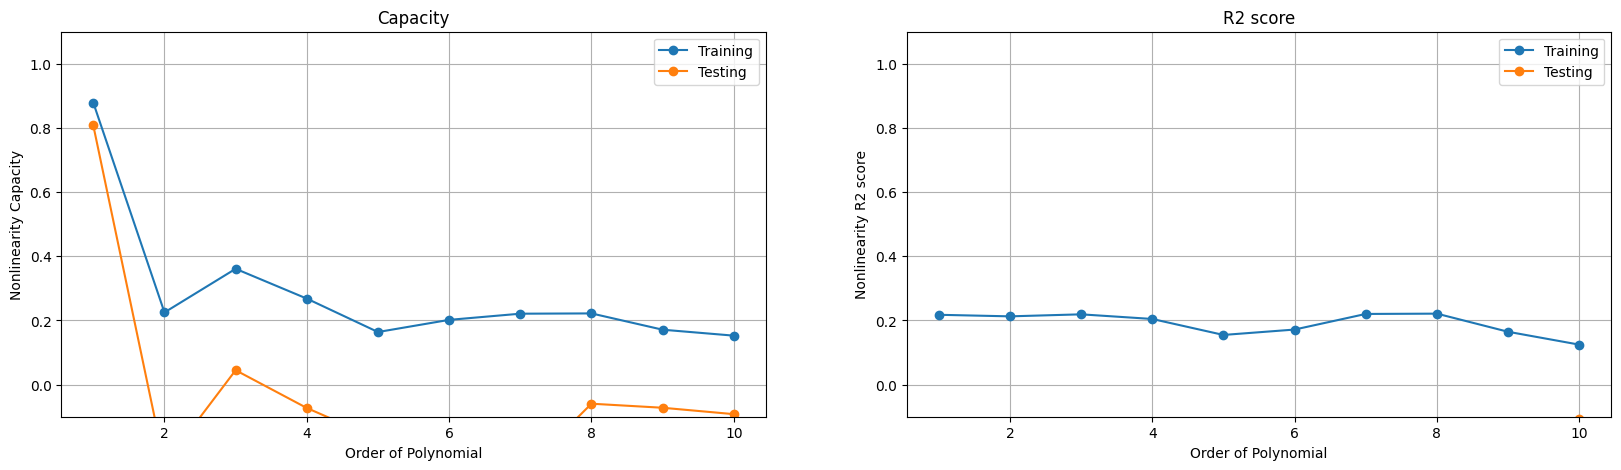

In [ ]:
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.plot(np.linspace(1, n_max, n_max), legendre_capacity_train, '-o', label='Training')
plt.plot(np.linspace(1, n_max, n_max), legendre_capacity_test, '-o', label='Testing')
plt.xlabel("Order of Polynomial")
plt.ylabel("Nonlinearity Capacity")
plt.ylim(-0.1, 1.1)
plt.title("Capacity")
plt.legend()
plt.grid(True)

plt.subplot(122)
plt.plot(np.linspace(1, n_max, n_max), legendre_R2_train, '-o', label='Training')
plt.plot(np.linspace(1, n_max, n_max), legendre_R2_test, '-o', label='Testing')
plt.xlabel("Order of Polynomial")
plt.ylabel("Nonlinearity R2 score")
plt.ylim(-0.1, 1.1)
plt.title("R2 score")
plt.legend()
plt.grid(True)

plt.show()

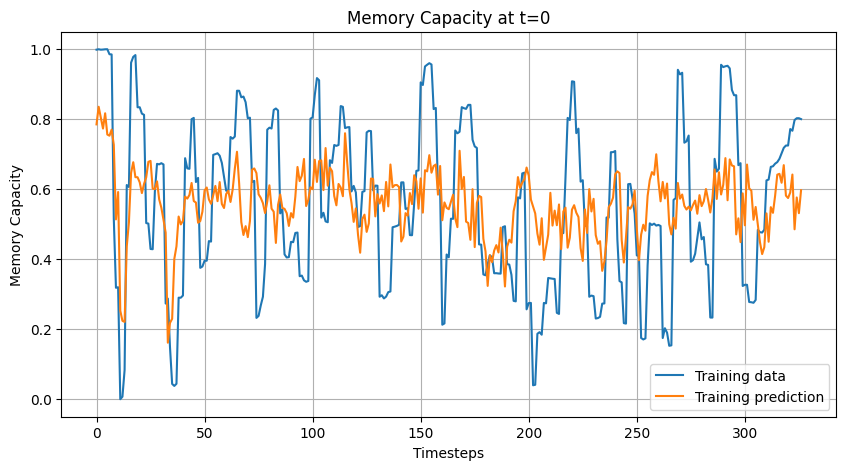

In [ ]:
test_size = 0.25
alpha = 0.5
clf = Ridge(alpha=alpha)
memory_capacity_train = []
memory_capacity_test = []
memory_R2_train = []
memory_R2_test = []

t_max = 10
for t in range(t_max+1):
    x = output[t:]
    if t == 0:
        y = input_signal
    else:
        y = input_signal[:-t]

    x_train, x_test, y_train, y_test = train_test_split(x, y, 
                                                        test_size=test_size,
                                                        random_state=42,
                                                        shuffle=False)
        
    
    clf.fit(x_train, y_train)

    # Training capacity
    y_train_pred = clf.predict(x_train)

    MSE = mean_squared_error(y_train, y_train_pred)
    y2 = (1/len(y_train)) * np.sum((y_train)**2)
    C = 1 - MSE/y2
    R2_train = r2_score(y_train, y_train_pred)

    memory_capacity_train.append(C)
    memory_R2_train.append(R2_train)

    # Testing capacity
    y_test_pred = clf.predict(x_test)

    MSE = mean_squared_error(y_test, y_test_pred)
    y2 = (1/len(y_test)) * np.sum((y_test)**2)
    C = 1 - MSE/y2
    R2_test = r2_score(y_test, y_test_pred)

    memory_capacity_test.append(C)
    memory_R2_test.append(R2_test)
    if t == 0:
        plt.figure(figsize=(10, 5))
        plt.plot(y_train, '-', label='Training data')
        plt.plot(y_train_pred, '-', label='Training prediction')
        plt.xlabel("Timesteps")
        plt.ylabel("Memory Capacity")
        plt.title(f"Memory Capacity at t={t}")
        plt.legend()
        plt.grid(True)
        plt.show()

memory_train = sum(memory_capacity_train)
memory_test = sum(memory_capacity_test)

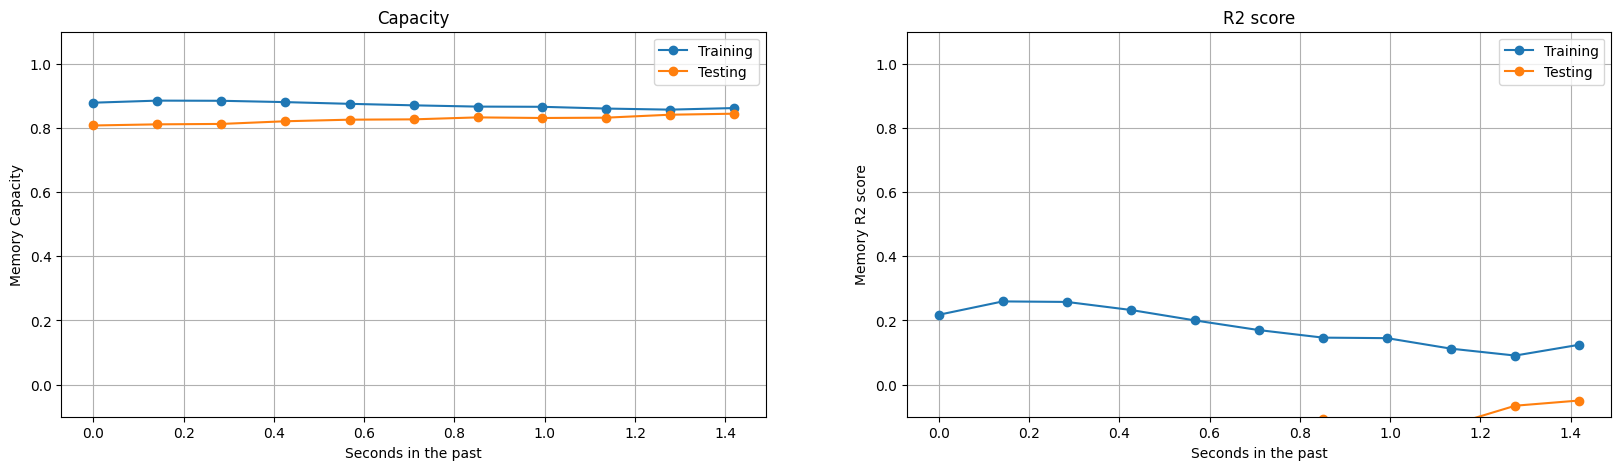

In [ ]:
t_max_seconds = t_max*62/min_shape
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.plot(np.linspace(0, t_max_seconds, t_max+1), memory_capacity_train, '-o', label='Training')
plt.plot(np.linspace(0, t_max_seconds, t_max+1), memory_capacity_test, '-o', label='Testing')
plt.xlabel("Seconds in the past")
plt.ylabel("Memory Capacity")
plt.ylim(-0.1, 1.1)
plt.title("Capacity")
plt.legend()
plt.grid(True)

plt.subplot(122)
plt.plot(np.linspace(0, t_max_seconds, t_max+1), memory_R2_train, '-o', label='Training')
plt.plot(np.linspace(0, t_max_seconds, t_max+1), memory_R2_test, '-o', label='Testing')
plt.xlabel("Seconds in the past")
plt.ylabel("Memory R2 score")
plt.ylim(-0.1, 1.1)
plt.title("R2 score")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
capacity_train_matrix = np.zeros((n_max, t_max+1))
capacity_test_matrix = np.zeros((n_max, t_max+1))
R2_train_matrix = np.zeros((n_max, t_max+1))
R2_test_matrix = np.zeros((n_max, t_max+1))

for n in range(1, n_max+1):
    leg = legendre(n)
    for t in range(t_max+1):
        x = output[t:]
        if t == 0:
            y = leg(input_signal)
        else:
            y = leg(input_signal[:-t])
    
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42, shuffle=False)
        clf.fit(x_train, y_train)

        # Training capacity
        y_train_pred = clf.predict(x_train)

        MSE = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
        z2 = (1/len(y_train)) * np.sum((y_train)**2)
        capacity_train = 1 - MSE/z2
        R2_train = r2_score(y_true=y_train, y_pred=y_train_pred)

        # Testing capacity
        y_test_pred = clf.predict(x_test)

        MSE = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
        z2 = (1/len(y_test)) * np.sum((y_test)**2)
        capacity_test = 1 - MSE/z2
        R2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

        capacity_train_matrix[n-1, t] = capacity_train
        capacity_test_matrix[n-1, t] = capacity_test
        R2_train_matrix[n-1, t] = R2_train
        R2_test_matrix[n-1, t] = R2_test

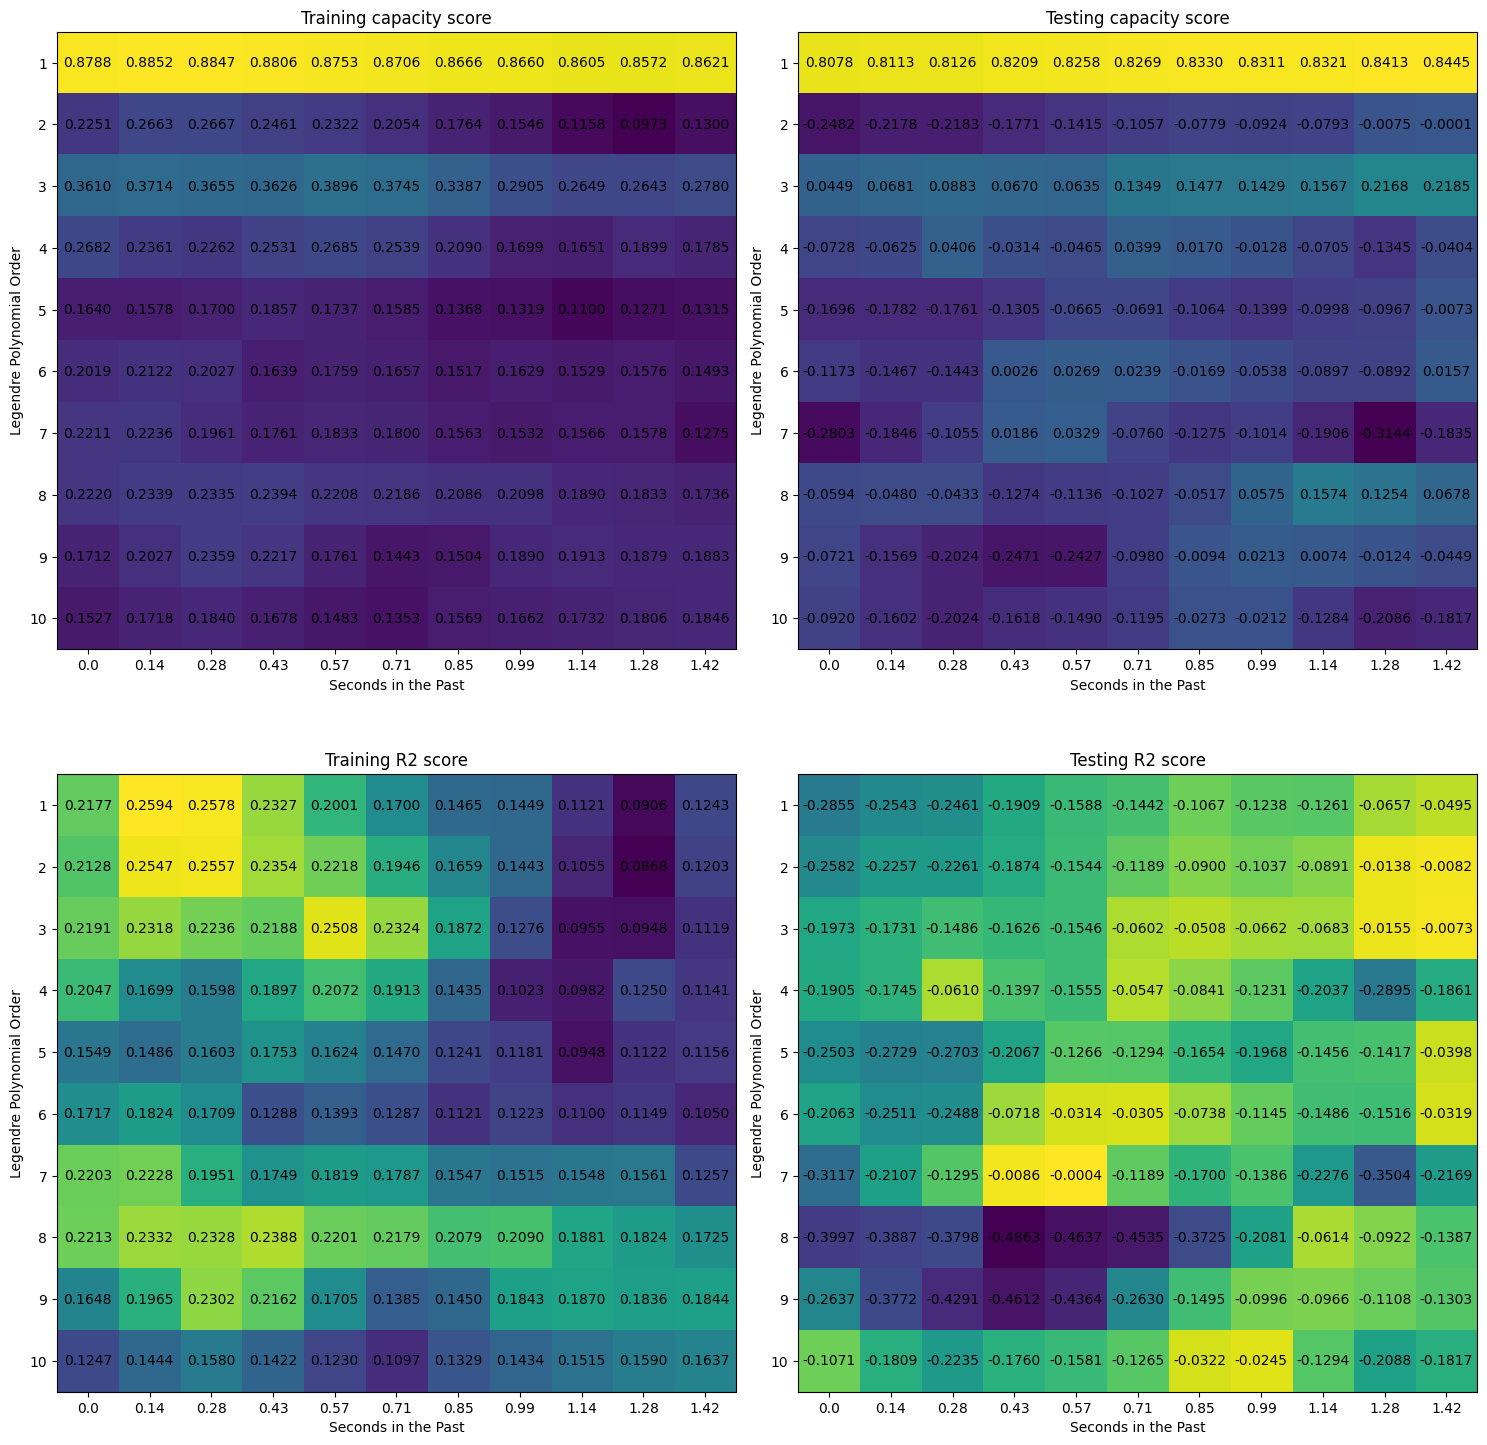

In [ ]:
import matplotlib
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 15))
ax1[0].matshow(capacity_train_matrix, cmap=matplotlib.colormaps['viridis'])
ax1[0].set_title("Training capacity score")
ax1[0].set_ylabel("Legendre Polynomial Order")
ax1[0].xaxis.set_ticks_position('bottom')  # Move xticks to the bottom
ax1[0].xaxis.set_label_position('bottom')  # Move xlabel to the bottom
ax1[0].set_xlabel("Seconds in the Past")
ax1[0].set_yticks(np.arange(n_max))
ax1[0].set_yticklabels(np.arange(1, n_max + 1))
ax1[0].set_xticks(np.arange(t_max+1))
ax1[0].set_xticklabels(np.round(np.linspace(0, t_max_seconds, t_max+1), 2))

ax1[1].matshow(capacity_test_matrix, cmap=matplotlib.colormaps['viridis'])
ax1[1].set_title("Testing capacity score")
ax1[1].set_ylabel("Legendre Polynomial Order")
ax1[1].xaxis.set_ticks_position('bottom')  # Move xticks to the bottom
ax1[1].xaxis.set_label_position('bottom')  # Move xlabel to the bottom
ax1[1].set_xlabel("Seconds in the Past")
ax1[1].set_yticks(np.arange(n_max))
ax1[1].set_yticklabels(np.arange(1, n_max + 1))
ax1[1].set_xticks(np.arange(t_max+1))
ax1[1].set_xticklabels(np.round(np.linspace(0, t_max_seconds, t_max+1), 2))

for i in range(1, n_max+1):
    for j in range(t_max+1):
        c_train = capacity_train_matrix[i-1, j]
        c_test = capacity_test_matrix[i-1, j]
        ax1[0].text(j, i-1, f"{c_train:.4f}", va='center', ha='center')
        ax1[1].text(j, i-1, f"{c_test:.4f}", va='center', ha='center')

ax2[0].matshow(R2_train_matrix, cmap=matplotlib.colormaps['viridis'])
ax2[0].set_title("Training R2 score")
ax2[0].set_ylabel("Legendre Polynomial Order")
ax2[0].xaxis.set_ticks_position('bottom')  # Move xticks to the bottom
ax2[0].xaxis.set_label_position('bottom')  # Move xlabel to the bottom
ax2[0].set_xlabel("Seconds in the Past")
ax2[0].set_yticks(np.arange(n_max))
ax2[0].set_yticklabels(np.arange(1, n_max + 1))
ax2[0].set_xticks(np.arange(t_max+1))
ax2[0].set_xticklabels(np.round(np.linspace(0, t_max_seconds, t_max+1), 2))

ax2[1].matshow(R2_test_matrix, cmap=matplotlib.colormaps['viridis'])
ax2[1].set_title("Testing R2 score")
ax2[1].set_ylabel("Legendre Polynomial Order")
ax2[1].xaxis.set_ticks_position('bottom')  # Move xticks to the bottom
ax2[1].xaxis.set_label_position('bottom')  # Move xlabel to the bottom
ax2[1].set_xlabel("Seconds in the Past")
ax2[1].set_yticks(np.arange(n_max))
ax2[1].set_yticklabels(np.arange(1, n_max + 1))
ax2[1].set_xticks(np.arange(t_max+1))
ax2[1].set_xticklabels(np.round(np.linspace(0, t_max_seconds, t_max+1), 2))

for i in range(1, n_max+1):
    for j in range(t_max+1):
        c_train = R2_train_matrix[i-1, j]
        c_test = R2_test_matrix[i-1, j]
        ax2[0].text(j, i-1, f"{c_train:.4f}", va='center', ha='center')
        ax2[1].text(j, i-1, f"{c_test:.4f}", va='center', ha='center')

plt.tight_layout()

plt.show()


In [ ]:
# # normalizing input between 0 and 0.5
# x = output
# input = (input_signal - np.min(input_signal)) / (np.max(input_signal) - np.min(input_signal)) * 0.5 + 0
# y = np.zeros(input.shape[0])

# capacity_train_list = []
# capacity_test_list = []
# R2_train_list = []
# R2_test_list = []
# n_list = [2, 5, 10]
# for n in n_list:
#     if n == 2:
#         a = 0.4
#         b = 0.4
#         g = 0.6
#         d = 0.1
#         for t in range(2, input.shape[0]):
#             alpha_term = a * y[t-1]
#             beta_term = b * y[t-1] * y[t-2]
#             gamma_term = g * input[t-1]**3
#             y[t] = alpha_term + beta_term + gamma_term + d

#     else:
#         a = 0.3
#         b = 0.05
#         g = 1.5
#         d = 0.1
#         for t in range(n, input.shape[0]):
#             alpha_term = a * y[t-1]
#             beta_term = b * y[t-1] * sum([y[t-i-1] for i in range(0, n)])
#             gamma_term = g * input[t-1] * input[t-n]
#             y[t] = alpha_term + beta_term + gamma_term + d
#             y[t] = np.clip(alpha_term + beta_term + gamma_term + d, -1e5, 1e5)
    
#     x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42, shuffle=False)
#     clf.fit(x_train, y_train)

#     # Training capacity
#     y_train_pred = clf.predict(x_train)

#     MSE = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
#     z2 = (1/len(y_train)) * np.sum((y_train)**2)
#     capacity_train = 1 - MSE/z2
#     R2_train = r2_score(y_true=y_train, y_pred=y_train_pred)

#     # Testing capacity
#     y_test_pred = clf.predict(x_test)

#     MSE = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
#     z2 = (1/len(y_test)) * np.sum((y_test)**2)
#     capacity_test = 1 - MSE/z2
#     R2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

#     if R2_test < 0:
#         R2_test = 0
#     if R2_train < 0:
#         R2_train = 0
#     if capacity_test < 0:
#         capacity_test = 0
#     if capacity_train < 0:
#         capacity_train = 0

#     capacity_train_list.append(capacity_train)
#     capacity_test_list.append(capacity_test)
#     R2_train_list.append(R2_train)
#     R2_test_list.append(R2_test)

In [ ]:
# plt.figure(figsize=(20, 10))
# plt.subplot(221)
# plt.plot(n_list, capacity_train_list, '-o')
# plt.xlabel("Number of Steps in the past")
# plt.ylabel("Memory Capacity")
# plt.ylim(-0.1, 1.1)
# plt.title("Training")
# plt.grid(True)

# plt.subplot(222)
# plt.plot(n_list, capacity_test_list, '-o')
# plt.xlabel("Number of Steps in the past")
# plt.ylabel("Memory Capacity")
# plt.ylim(-0.1, 1.1)
# plt.title("Testing")
# plt.grid(True)

# plt.subplot(223)
# plt.plot(n_list, R2_train_list, '-o')
# plt.xlabel("Number of Steps in the past")
# plt.ylabel("Memory Capacity")
# plt.ylim(-0.1, 1.1)
# plt.title("Training")
# plt.grid(True)

# plt.subplot(224)
# plt.plot(n_list, R2_test_list, '-o')
# plt.xlabel("Number of Steps in the past")
# plt.ylabel("Memory Capacity")
# plt.ylim(-0.1, 1.1)
# plt.title("Testing")
# plt.grid(True)


# plt.show()

In [ ]:
# from scipy.interpolate import CubicSpline
# import time
# angle_conversion = 1023/300
# duration = 60                                               # seconds
# freq = 2                                                    # Hz
# size = int(duration*freq*0.5)
# stiffness = 3
# mean = 230 #245
# rng = 50
# min_angle = np.rint((mean-rng) * angle_conversion).astype(int)
# max_angle = np.rint(mean * angle_conversion).astype(int)
# # mid_angle = np.rint((mean-0.5*rng) * angle_conversion).astype(int)
# # max_angle = np.rint(300 * angle_conversion).astype(int)
# goal_positions = np.random.uniform(min_angle, max_angle, size=(size)).astype(int)
# time_arr = np.linspace(0, duration, num=size)
# spline = CubicSpline(time_arr, goal_positions)
# dxl_goal_position = [i for i in spline(time_arr)]

# start_time = time.time()
# actual_goal_position = []
# while (time.time() - start_time) <= duration:
#     time.sleep(0.1)
#     actual_goal_position.append(spline(time.time() - start_time).astype(int))
# plt.figure(figsize=(10, 5))
# plt.plot(time_arr, dxl_goal_position, '-o', label='GoalPos')
# plt.plot(actual_goal_position, '-o', label='ActualPos')
# plt.show()

In [ ]:
# data_list = []
# for i in range(1, 4):
#     data = pd.read_csv(f'{filepath}/pre_strained_sine_clipped_20s_{i}/clean_data.csv')
#     origin_x = data['Xmm'].min()
#     origin_y = data['Ymm'].min()
#     data['Relative X'] = data['Xmm'] - origin_x
#     data['Relative Y'] = data['Ymm'] - origin_y
#     data_list.append(data)

In [ ]:
# input_freq = 2
# clip = [171, 147, 167]
# for j in range(3):
#     clean_data = data_list[j]
#     min_label = clean_data['Label'].min()
#     max_label = clean_data['Label'].max()
#     for i in range(min_label, max_label+1):
#         one_over_time = clean_data[clean_data['Label']==i]
#         one_over_time = one_over_time.iloc[:, 7:]
#         array = one_over_time.to_numpy()
#         array = array[:clip[j], :]
#         if i == 0:
#             op = array
#         else:
#             op = np.hstack([op, array])

#     op = np.nan_to_num(op, nan=0)
#     op /= np.mean(op, axis=0) # mean is calculated along the rows i.e., the number of columns stay the same
#     op /= np.std(op, axis=0)

#     ip = np.zeros(op.shape[0])
#     time = np.linspace(0, 23, op.shape[0])
#     ip[2*3:-2*2*3] = np.sin(2 * np.pi * input_freq * time[:-3*2*3])

#     if j == 0:
#         output_signal = op
#         input_signal = ip
#     else:
#         output_signal = np.vstack([output_signal, op])
#         input_signal = np.hstack([input_signal, ip])


# scaler = preprocessing.StandardScaler().fit(output_signal)
# output_signal = scaler.transform(output_signal)
# print(output_signal.shape, input_signal.shape)

In [ ]:
# test_size = 0.25
# alpha = 0.5
# clf = Ridge(alpha=alpha)

# # normalizing input between 0 and 0.5
# x = output_signal
# input_signal = (input_signal - np.min(input_signal)) / (np.max(input_signal) - np.min(input_signal)) * 0.5 + 0
# y = np.zeros(input_signal.shape[0])

# capacity_train_list = []
# capacity_test_list = []
# R2_train_list = []
# R2_test_list = []
# n_list = [2, 5, 10]
# for n in n_list:
#     if n == 2:
#         a = 0.4
#         b = 0.4
#         g = 0.6
#         d = 0.1
#         for t in range(2, input_signal.shape[0]):
#             alpha_term = a * y[t-1]
#             beta_term = b * y[t-1] * y[t-2]
#             gamma_term = g * input_signal[t]**3
#             y[t] = alpha_term + beta_term + gamma_term + d

#     else:
#         a = 0.3
#         b = 0.05
#         g = 1.5
#         d = 0.1
#         for t in range(n, input_signal.shape[0]):
#             alpha_term = a * y[t-1]
#             beta_term = b * y[t-1] * sum([y[t-i-1] for i in range(0, n)])
#             gamma_term = g * input_signal[t-1] * input_signal[t-n]
#             y[t] = alpha_term + beta_term + gamma_term + d
#             y[t] = np.clip(alpha_term + beta_term + gamma_term + d, -1e5, 1e5)
    
#     x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42, shuffle=False)
#     clf.fit(x_train, y_train)

#     # Training capacity
#     y_train_pred = clf.predict(x_train)

#     MSE = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
#     z2 = (1/len(y_train)) * np.sum((y_train)**2)
#     capacity_train = 1 - MSE/z2
#     R2_train = r2_score(y_true=y_train, y_pred=y_train_pred)

#     # Testing capacity
#     y_test_pred = clf.predict(x_test)

#     MSE = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
#     z2 = (1/len(y_test)) * np.sum((y_test)**2)
#     capacity_test = 1 - MSE/z2
#     R2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

#     if R2_test < 0:
#         R2_test = 0
#     if R2_train < 0:
#         R2_train = 0
#     if capacity_test < 0:
#         capacity_test = 0
#     if capacity_train < 0:
#         capacity_train = 0

#     capacity_train_list.append(capacity_train)
#     capacity_test_list.append(capacity_test)
#     R2_train_list.append(R2_train)
#     R2_test_list.append(R2_test)

In [ ]:
# plt.figure(figsize=(20, 5))
# plt.subplot(121)
# plt.plot(n_list, capacity_train_list, '-o', label="Training")
# plt.plot(n_list, capacity_test_list, '-o', label="Testing")
# plt.xlabel("Order of NARMA")
# plt.ylabel("Capacity")
# plt.ylim(-0.1, 1.1)
# plt.title("NARMA-N Capacity")
# plt.legend()
# plt.grid(True)

# plt.subplot(122)
# plt.plot(n_list, R2_train_list, '-o', label="Training")
# plt.plot(n_list, R2_test_list, '-o', label="Testing")
# plt.xlabel("Order of NARMA")
# plt.ylabel("R2 Score")
# plt.ylim(-0.1, 1.1)
# plt.title("NARMA-N R2 Score")
# plt.legend()
# plt.grid(True)

# plt.show()

In [ ]:
# test_size = 0.25
# alpha = 1
# clf = Ridge(alpha=alpha)

# narma2 = np.zeros(input_signal.shape[0])
# narma5 = np.zeros(input_signal.shape[0])
# narma10 = np.zeros(input_signal.shape[0])
# a = 0.4
# b = 0.4
# g = 0.6
# d = 0.1
# for t in range(2, input_signal.shape[0]):
#     alpha_term = a * narma2[t-1]
#     beta_term = b * narma2[t-1] * narma2[t-2]
#     gamma_term = g * input_signal[t]**3
#     narma2[t] = alpha_term + beta_term + gamma_term + d

# a = 0.3
# b = 0.05
# g = 1.5
# d = 0.1
# n = 5
# for t in range(n, input_signal.shape[0]):
#     alpha_term = a * narma5[t-1]
#     beta_term = b * narma5[t-1] * sum([narma5[t-i-1] for i in range(0, n)])
#     gamma_term = g * input_signal[t-1] * input_signal[t-n]
#     narma5[t] = alpha_term + beta_term + gamma_term + d
#     narma5[t] = np.clip(alpha_term + beta_term + gamma_term + d, -1e5, 1e5)

# n = 10
# for t in range(n, input_signal.shape[0]):
#     alpha_term = a * narma10[t-1]
#     beta_term = b * narma10[t-1] * sum([narma10[t-i-1] for i in range(0, n)])
#     gamma_term = g * input_signal[t-1] * input_signal[t-n]
#     narma10[t] = alpha_term + beta_term + gamma_term + d
#     narma10[t] = np.clip(alpha_term + beta_term + gamma_term + d, -1e5, 1e5)

# x_train, x_test, narma2_train, narma2_test = train_test_split(x, narma2, test_size=test_size, random_state=42, shuffle=False)
# clf.fit(x_train, narma2_train)

# # Training capacity
# narma2_train_pred = clf.predict(x_train)
# MSE2_train = mean_squared_error(y_true=narma2_train, y_pred=narma2_train_pred)

# # Testing capacity
# narma2_test_pred = clf.predict(x_test)
# MSE2_test = mean_squared_error(y_true=narma2_test, y_pred=narma2_test_pred)

# x_train, x_test, narma5_train, narma5_test = train_test_split(x, narma5, test_size=test_size, random_state=42, shuffle=False)
# clf.fit(x_train, narma5_train)

# # Training capacity
# narma5_train_pred = clf.predict(x_train)
# MSE5_train = mean_squared_error(y_true=narma5_train, y_pred=narma5_train_pred)

# # Testing capacity
# narma5_test_pred = clf.predict(x_test)
# MSE5_test = mean_squared_error(y_true=narma5_test, y_pred=narma5_test_pred)

# x_train, x_test, narma10_train, narma10_test = train_test_split(x, narma10, test_size=test_size, random_state=42, shuffle=False)
# clf.fit(x_train, narma10_train)

# # Training capacity
# narma10_train_pred = clf.predict(x_train)
# MSE10_train = mean_squared_error(y_true=narma10_train, y_pred=narma10_train_pred)

# # Testing capacity
# narma10_test_pred = clf.predict(x_test)
# MSE10_test = mean_squared_error(y_true=narma10_test, y_pred=narma10_test_pred)

In [ ]:
# print(f"The mean squared error for NARMA2 training is: {MSE2_train}, testing is: {MSE2_test}")
# print(f"The mean squared error for NARMA5 training is: {MSE5_train}, testing is: {MSE5_test}")
# print(f"The mean squared error for NARMA10 training is: {MSE10_train}, testing is: {MSE10_test}")

In [ ]:
# plt.figure(figsize=(20, 15))
# plt.subplot(321)
# plt.plot(narma2_train, '-o', label="True")
# plt.plot(narma2_train_pred, '-o', label="Predicted")
# plt.xlabel("Time")
# plt.ylabel("NARMA2")
# plt.title("Training")
# plt.legend()
# plt.grid(True)

# plt.subplot(322)
# plt.plot(narma2_test, '-o', label="True")
# plt.plot(narma2_test_pred, '-o', label="Predicted")
# plt.xlabel("Time")
# plt.ylabel("NARMA2")
# plt.title("Testing")
# plt.legend()
# plt.grid(True)

# plt.subplot(323)
# plt.plot(narma5_train, '-o', label="True")
# plt.plot(narma5_train_pred, '-o', label="Predicted")
# plt.xlabel("Time")
# plt.ylabel("NARMA5")
# plt.title("Training")
# plt.legend()
# plt.grid(True)

# plt.subplot(324)
# plt.plot(narma5_test, '-o', label="True")
# plt.plot(narma5_test_pred, '-o', label="Predicted")
# plt.xlabel("Time")
# plt.ylabel("NARMA5")
# plt.title("Testing")
# plt.legend()
# plt.grid(True)

# plt.subplot(325)
# plt.plot(narma10_train, '-o', label="True")
# plt.plot(narma10_train_pred, '-o', label="Predicted")
# plt.xlabel("Time")
# plt.ylabel("NARMA10")
# plt.title("Training")
# plt.legend()
# plt.grid(True)

# plt.subplot(326)
# plt.plot(narma10_test, '-o', label="True")
# plt.plot(narma10_test_pred, '-o', label="Predicted")
# plt.xlabel("Time")
# plt.ylabel("NARMA10")
# plt.title("Testing")
# plt.legend()
# plt.grid(True)

# plt.show()